# 02 - Modélisation, score métier et MLflow

Objectifs :

- entraîner plusieurs modèles de classification ;
- gérer le déséquilibre des classes ;
- comparer les modèles avec des métriques techniques et métier ;
- optimiser LightGBM avec `GridSearchCV` ;
- optimiser le seuil de décision selon le coût métier ;
- enregistrer les expériences et le modèle final dans MLflow.


In [1]:
from pathlib import Path
import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from lightgbm import LGBMClassifier

import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Racine projet :', PROJECT_ROOT)

Racine projet : C:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring


## 1. Chargement du dataset préparé

Ce notebook suppose que `01_exploration_preparation.ipynb` a été exécuté et que le fichier `home_credit_train_processed.csv` existe dans `data/processed/`.


In [2]:
train_path = PROCESSED_DIR / 'home_credit_train_processed.csv'

if not train_path.exists():
    raise FileNotFoundError(
        f"Le fichier {train_path} est introuvable. Exécute d'abord le notebook 01."
    )

df = pd.read_csv(train_path)
print(df.shape)
df.head()

(307511, 1610)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,...,CC_CNT_DRAWINGS_ATM_CURRENT_MIN,CC_CNT_DRAWINGS_ATM_CURRENT_MAX,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,CC_CNT_DRAWINGS_ATM_CURRENT_SUM,CC_CNT_DRAWINGS_CURRENT_MIN,CC_CNT_DRAWINGS_CURRENT_MAX,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_SUM,CC_CNT_DRAWINGS_OTHER_CURRENT_MIN,CC_CNT_DRAWINGS_OTHER_CURRENT_MAX,CC_CNT_DRAWINGS_OTHER_CURRENT_MEAN,CC_CNT_DRAWINGS_OTHER_CURRENT_SUM,CC_CNT_DRAWINGS_POS_CURRENT_MIN,CC_CNT_DRAWINGS_POS_CURRENT_MAX,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,CC_CNT_DRAWINGS_POS_CURRENT_SUM,CC_CNT_INSTALMENT_MATURE_CUM_MIN,CC_CNT_INSTALMENT_MATURE_CUM_MAX,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_SUM,CC_SK_DPD_MIN,CC_SK_DPD_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_SUM,CC_SK_DPD_DEF_MIN,CC_SK_DPD_DEF_MAX,CC_SK_DPD_DEF_MEAN,CC_SK_DPD_DEF_SUM,CC_NAME_CONTRACT_STATUS_ACTIVE_MIN,CC_NAME_CONTRACT_STATUS_ACTIVE_MAX,CC_NAME_CONTRACT_STATUS_ACTIVE_MEAN,CC_NAME_CONTRACT_STATUS_ACTIVE_SUM,CC_NAME_CONTRACT_STATUS_APPROVED_MIN,CC_NAME_CONTRACT_STATUS_APPROVED_MAX,CC_NAME_CONTRACT_STATUS_APPROVED_MEAN,CC_NAME_CONTRACT_STATUS_APPROVED_SUM,CC_NAME_CONTRACT_STATUS_COMPLETED_MIN,CC_NAME_CONTRACT_STATUS_COMPLETED_MAX,CC_NAME_CONTRACT_STATUS_COMPLETED_MEAN,CC_NAME_CONTRACT_STATUS_COMPLETED_SUM,CC_NAME_CONTRACT_STATUS_DEMAND_MIN,CC_NAME_CONTRACT_STATUS_DEMAND_MAX,CC_NAME_CONTRACT_STATUS_DEMAND_MEAN,CC_NAME_CONTRACT_STATUS_DEMAND_SUM,CC_NAME_CONTRACT_STATUS_REFUSED_MIN,CC_NAME_CONTRACT_STATUS_REFUSED_MAX,CC_NAME_CONTRACT_STATUS_REFUSED_MEAN,CC_NAME_CONTRACT_STATUS_REFUSED_SUM,CC_NAME_CONTRACT_STATUS_SENT_PROPOSAL_MIN,CC_NAME_CONTRACT_STATUS_SENT_PROPOSAL_MAX,CC_NAME_CONTRACT_STATUS_SENT_PROPOSAL_MEAN,CC_NAME_CONTRACT_STATUS_SENT_PROPOSAL_SUM,CC_NAME_CONTRACT_STATUS_SIGNED_MIN,CC_NAME_CONTRACT_STATUS_SIGNED_MAX,CC_NAME_CONTRACT_STATUS_SIGNED_MEAN,CC_NAME_CONTRACT_STATUS_SIGNED_SUM,CC_NAME_CONTRACT_STATUS_NAN_MIN,CC_NAME_CONTRACT_STATUS_NAN_MAX,CC_NAME_CONTRACT_STATUS_NAN_MEAN,CC_NAME_CONTRACT_STATUS_NAN_SUM
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,-3648.0,-2120,NaN,1,1,0,1,1,0,1.0,2,2,10,0,0,0,0,0,0,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,-1186.0,-291,NaN,1,1,0,1,1,0,2.0,1,1,11,0,0,0,0,0,0,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
TARGET = 'TARGET'
ID_COLS = [c for c in ['SK_ID_CURR'] if c in df.columns]

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

if ID_COLS:
    X_ids = X[ID_COLS].copy()
    X = X.drop(columns=ID_COLS)

X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train :', X_train.shape)
print('X_test  :', X_test.shape)
print('Taux de défaut train :', y_train.mean())
print('Taux de défaut test  :', y_test.mean())

X_train : (246008, 1608)
X_test  : (61503, 1608)
Taux de défaut train : 0.08072908198107379
Taux de défaut test  : 0.08072776937710356


## 2. Fonction de coût métier

Dans ce projet, un **faux négatif** est plus grave qu'un faux positif :

- FN : mauvais client prédit bon client -> crédit accordé -> perte en capital ;
- FP : bon client prédit mauvais client -> crédit refusé -> manque à gagner.

On suppose ici que le coût d'un FN est 10 fois supérieur au coût d'un FP.


In [4]:
def business_cost(y_true, y_proba, threshold=0.5, cost_fn=10, cost_fp=1):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = cost_fn * fn + cost_fp * fp
    return cost, tn, fp, fn, tp


def find_best_threshold(y_true, y_proba, cost_fn=10, cost_fp=1):
    thresholds = np.arange(0.01, 0.99, 0.01)
    rows = []
    for threshold in thresholds:
        cost, tn, fp, fn, tp = business_cost(y_true, y_proba, threshold, cost_fn=cost_fn, cost_fp=cost_fp)
        rows.append({'threshold': threshold, 'business_cost': cost, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp})
    costs_df = pd.DataFrame(rows)
    best_row = costs_df.loc[costs_df['business_cost'].idxmin()]
    return float(best_row['threshold']), float(best_row['business_cost']), costs_df

## 3. Configuration MLflow

Les runs sont stockés dans le dossier local `mlruns/` du projet.

Depuis la racine du projet, lancer :

```powershell
mlflow ui
```

Puis ouvrir : `http://127.0.0.1:5000`.


In [5]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("pret_a_depenser_scoring")

print("Tracking URI :", mlflow.get_tracking_uri())

Tracking URI : http://127.0.0.1:5000


## 4. Comparaison de plusieurs modèles

Les modèles linéaires et RandomForest nécessitent une imputation des valeurs manquantes. On utilise donc un `Pipeline` avec `SimpleImputer`.


In [6]:
# Réduction du dataset pour éviter les erreurs mémoire

import numpy as np
import pandas as pd

print("Avant réduction :", X_train.shape)

# 1. Garder uniquement les colonnes numériques
X_train = X_train.select_dtypes(include=["number"])
X_test = X_test.select_dtypes(include=["number"])

# 2. Supprimer les colonnes totalement vides
X_train = X_train.dropna(axis=1, how="all")
X_test = X_test[X_train.columns]

# 3. Supprimer les colonnes constantes
nunique = X_train.nunique(dropna=False)
cols_to_keep = nunique[nunique > 1].index

X_train = X_train[cols_to_keep]
X_test = X_test[cols_to_keep]

# 4. Limiter à 300 colonnes les plus corrélées avec la cible
corr_with_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)
top_features = corr_with_target.head(300).index

X_train = X_train[top_features]
X_test = X_test[top_features]

# 5. Convertir en float32 pour économiser la mémoire
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

print("Après réduction :", X_train.shape)

Avant réduction : (246008, 1608)
Après réduction : (246008, 300)


In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

models = {
    "Dummy": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="prior"))
    ]),

    "RandomForest_light": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=50,
            max_depth=8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "LightGBM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

In [10]:
results = []

for name, pipeline in models.items():
    print('Entraînement :', name)
    with mlflow.start_run(run_name=name):
        pipeline.fit(X_train, y_train)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        best_threshold, best_cost, costs_df = find_best_threshold(y_test, y_proba)
        y_pred = (y_proba >= best_threshold).astype(int)

        metrics = {
            'auc': roc_auc_score(y_test, y_proba),
            'accuracy': accuracy_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'business_cost': best_cost
        }

        mlflow.log_param('model', name)
        mlflow.log_param('best_threshold', best_threshold)
        for k, v in metrics.items():
            mlflow.log_metric(k, float(v))

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            serialization_format="cloudpickle"
        )
    
        results.append({'model': name, 'threshold': best_threshold, **metrics})

results_df = pd.DataFrame(results).sort_values('business_cost')
results_df

Entraînement : Dummy


2026/07/08 16:01:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Dummy at: http://127.0.0.1:5000/#/experiments/1/runs/0e160ce06f5a4f499f44e1f64ea8a231
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Entraînement : RandomForest_light


2026/07/08 16:02:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_light at: http://127.0.0.1:5000/#/experiments/1/runs/72184a562305455e992157025df3454f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.238384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47214
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 300
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


2026/07/08 16:02:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM at: http://127.0.0.1:5000/#/experiments/1/runs/abe8263dca184fe9acc3235a2790b2b6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


,model,threshold,auc,accuracy,recall,f1_score,business_cost
2,LightGBM,0.49,0.773612,0.719298,0.687210,0.283295,31241.0
1,RandomForest_light,0.52,0.741150,0.748451,0.585498,0.273150,33993.0
0,Dummy,0.09,0.500000,0.919272,0.000000,0.000000,49650.0


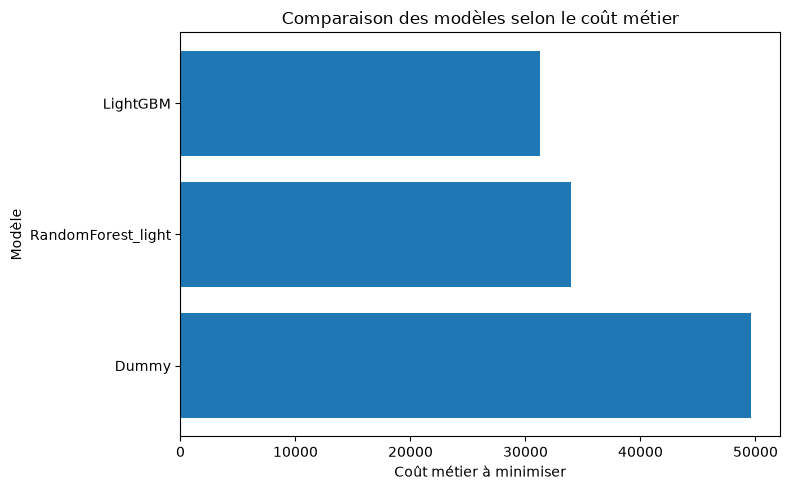

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(results_df['model'], results_df['business_cost'])
plt.title('Comparaison des modèles selon le coût métier')
plt.xlabel('Coût métier à minimiser')
plt.ylabel('Modèle')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Optimisation de LightGBM avec GridSearchCV

LightGBM est retenu comme modèle principal car il est performant sur les données tabulaires et rapide à entraîner. On optimise quelques hyperparamètres avec validation croisée stratifiée.


In [12]:
param_grid = {
    'model__n_estimators': [300, 500],
    'model__learning_rate': [0.03, 0.05],
    'model__num_leaves': [31, 63],
    'model__max_depth': [-1, 8]
}

lgbm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

grid.fit(X_train, y_train)

print('Meilleurs hyperparamètres :')
print(grid.best_params_)
print('Meilleure AUC CV :', grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.321217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47214
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 300
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Meilleurs hyperparamètres :
{'model__learning_rate': 0.03, 'model__max_depth': -1, 'model__n_estimators': 300, 'model__num_leaves': 31}
Meilleure AUC CV : 0.7687707310772341


In [15]:
best_model = grid.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]
best_threshold, best_cost, costs_df = find_best_threshold(y_test, y_proba)
y_pred = (y_proba >= best_threshold).astype(int)

print('Seuil métier optimal :', best_threshold)
print('Coût métier minimal :', best_cost)
print('Matrice de confusion :')
print(confusion_matrix(y_test, y_pred))
print('Rapport de classification :')
print(classification_report(y_test, y_pred))

Seuil métier optimal : 0.48000000000000004
Coût métier minimal : 31290.0
Matrice de confusion :
[[39378 17160]
 [ 1413  3552]]
Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.70      0.81     56538
           1       0.17      0.72      0.28      4965

    accuracy                           0.70     61503
   macro avg       0.57      0.71      0.54     61503
weighted avg       0.90      0.70      0.77     61503



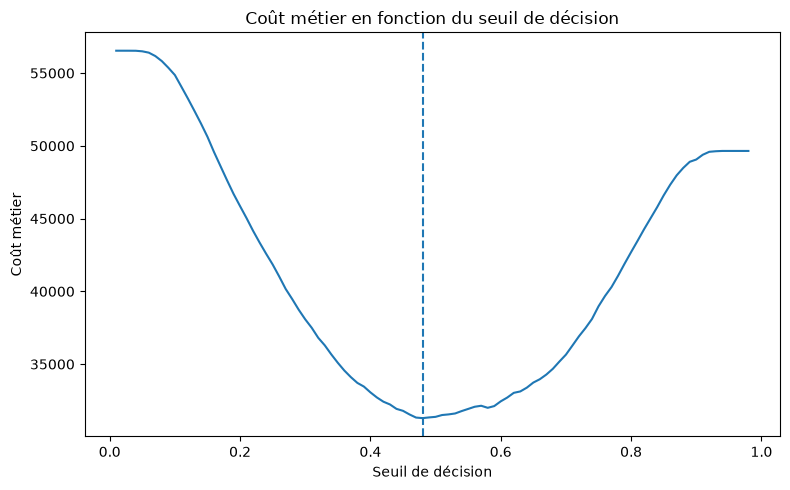

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(costs_df['threshold'], costs_df['business_cost'])
plt.axvline(best_threshold, linestyle='--')
plt.title('Coût métier en fonction du seuil de décision')
plt.xlabel('Seuil de décision')
plt.ylabel('Coût métier')
plt.tight_layout()
plt.show()

## 6. Enregistrement du modèle final dans MLflow et en local

On enregistre les meilleurs hyperparamètres, le seuil métier optimal, les métriques finales et le modèle final.


In [17]:
final_metrics = {
    'auc': roc_auc_score(y_test, y_proba),
    'accuracy': accuracy_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'business_cost': best_cost
}

with mlflow.start_run(run_name='LightGBM_final_optimized') as run:
    mlflow.log_params(grid.best_params_)
    mlflow.log_param('best_threshold', best_threshold)
    mlflow.log_param('cost_fn', 10)
    mlflow.log_param('cost_fp', 1)

    for k, v in final_metrics.items():
        mlflow.log_metric(k, float(v))

    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path='model',
        registered_model_name='credit_scoring_lightgbm',
        serialization_format='cloudpickle'
    )

    final_run_id = run.info.run_id

joblib.dump(best_model, MODELS_DIR / 'best_lightgbm.joblib')
with open(MODELS_DIR / 'best_threshold.json', 'w', encoding='utf-8') as f:
    json.dump({'best_threshold': best_threshold}, f, indent=2)
with open(MODELS_DIR / 'feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(list(X_train.columns), f, indent=2)

print('Run final MLflow :', final_run_id)
print('Métriques finales :', final_metrics)
print('Modèle sauvegardé dans :', MODELS_DIR / 'best_lightgbm.joblib')

2026/07/08 16:19:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 16:19:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'credit_scoring_lightgbm'.
2026/07/08 16:19:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit_scoring_lightgbm, version 1


🏃 View run LightGBM_final_optimized at: http://127.0.0.1:5000/#/experiments/1/runs/b93dd0ebfd314b5b811fd6154009b72a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run final MLflow : b93dd0ebfd314b5b811fd6154009b72a
Métriques finales : {'auc': 0.7729551766678896, 'accuracy': 0.6980147309887322, 'recall': 0.7154078549848942, 'f1_score': 0.27666783502745645, 'business_cost': 31290.0}
Modèle sauvegardé dans : C:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring\models\best_lightgbm.joblib


Created version '1' of model 'credit_scoring_lightgbm'.


## 7. Commandes MLflow utiles

### Lancer l'interface MLflow

Depuis la racine du projet :

```powershell
mlflow ui
```

Puis ouvrir : `http://127.0.0.1:5000`.

### Tester le serving MLflow

Copier le `run_id` du modèle final, puis lancer :

```powershell
mlflow models serve -m runs:/TON_RUN_ID/model -p 5001 --no-conda
```

Pour le rendu demandé, la capture importante est la page MLflow avec les runs et les métriques.


## Conclusion du notebook 2

Le modèle final est un LightGBM optimisé. Il est sélectionné en tenant compte du déséquilibre des classes et du coût métier. Le seuil de décision n'est pas fixé à 0,5 : il est optimisé pour minimiser le coût des erreurs, en pénalisant plus fortement les faux négatifs.
